In [ ]:
  Imports

In [ ]:
#the imports and setup
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Unzip the image data
if not os.path.exists('lake_bird_images'):
    !unzip -q lake_bird_images.zip

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Define paths
train_dir = 'lake_bird_images/train'
test_dir = 'lake_bird_images/test'

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Calculate class weights
def calculate_class_weights(train_dir):
    """Calculate class weights to handle imbalance"""
    class_counts = []
    class_names = ['duck', 'goose', 'swan']

    for class_name in class_names:
        class_path = os.path.join(train_dir, class_name)
        count = len([f for f in os.listdir(class_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts.append(count)

    print(f"Class counts: {dict(zip(class_names, class_counts))}")

    # Calculate weights (inverse frequency)
    total = sum(class_counts)
    class_weights = {}
    for i, count in enumerate(class_counts):
        # Higher weight for minority classes
        class_weights[i] = total / (len(class_counts) * count)

    print(f"Class weights: {class_weights}")
    return class_weights, class_names

class_weights, class_names = calculate_class_weights(train_dir)

# Create data generators with improved augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# Test generator
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Class counts: {'duck': 498, 'goose': 981, 'swan': 335}
Class weights: {0: 1.214190093708166, 1: 0.6163778457356439, 2: 1.8049751243781094}
Found 1452 images belonging to 3 classes.
Found 362 images belonging to 3 classes.
Found 783 images belonging to 3 classes.


In [ ]:
def create_optimized_cnn(learning_rate=0.001):
    """Create an optimized CNN model"""

    # Clear any existing models
    keras.backend.clear_session()

    model = models.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Third convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Fourth convolutional block (new)
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Global Average Pooling instead of Flatten + Dense
        layers.GlobalAveragePooling2D(),

        # Dense layers with reduced size
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Output layer
        layers.Dense(3, activation='softmax')
    ])

    # Compile with Adam optimizer (not learning rate schedule)
    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create the optimized model
model = create_optimized_cnn(learning_rate=0.001)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,276,707 (4.87 MB)

 Trainable params: 1,274,019 (4.86 MB)

 Non-trainable params: 2,688 (10.50 KB)

train

In [ ]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        min_delta=0.005,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_optimized_cnn.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# Calculate steps per epoch
train_steps = max(1, train_generator.samples // BATCH_SIZE)
val_steps = max(1, validation_generator.samples // BATCH_SIZE)

print(f"Training steps per epoch: {train_steps}")
print(f"Validation steps per epoch: {val_steps}")

# Train the model
print("Training optimized CNN model...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=100,  # More epochs with early stopping
    validation_data=validation_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    class_weight=class_weights,  # Use class weights
    verbose=1
)

Training steps per epoch: 45
Validation steps per epoch: 11
Training optimized CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.3673 - loss: 1.6586
Epoch 1: val_accuracy improved from -inf to 0.19034, saving model to best_optimized_cnn.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.3675 - loss: 1.6558 - val_accuracy: 0.1903 - val_loss: 1.3428 - learning_rate: 0.0010
Epoch 2/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - accuracy: 0.4688 - loss: 1.1190

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.19034
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.4688 - loss: 1.1190 - val_accuracy: 0.1875 - val_loss: 1.3264 - learning_rate: 0.0010
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.4347 - loss: 1.2638
Epoch 3: val_accuracy improved from 0.19034 to 0.40057, saving model to best_optimized_cnn.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 579ms/step - accuracy: 0.4344 - loss: 1.2643 - val_accuracy: 0.4006 - val_loss: 1.8219 - learning_rate: 0.0010
Epoch 4/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step - accuracy: 0.4375 - loss: 1.2813
Epoch 4: val_accuracy did not improve from 0.40057
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.4375 - loss: 1.2813 - val_accuracy: 0.3949 - val_loss: 1.7886 - learning_rate: 0.0010
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.4170 - loss: 1.2805
Epoch 5: val_accuracy did not improve from 0.40057
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 579ms/step - accuracy: 0.4170 - loss: 1.2809 - val_accuracy: 0.3324 - val_loss: 1.3873 - learning_rate: 0.0010
Epoch 6/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 8s 184ms/step - accuracy: 0.4688 - loss: 1.2946
Epoch 6: val_accuracy did not improve from 0.40057
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.4688 - loss: 1.2946 - val_accuracy: 0.3324 - val_loss: 1.2750 - learning_rate: 0.0010
Epoch 7/100
45/45 ━━

45/45 ━━━━━━━━━━━━━━━━━━━━ 27s 588ms/step - accuracy: 0.4283 - loss: 1.1747 - val_accuracy: 0.5142 - val_loss: 0.9947 - learning_rate: 0.0010
Epoch 12/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.4688 - loss: 0.9382
Epoch 12: val_accuracy improved from 0.51420 to 0.51705, saving model to best_optimized_cnn.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.4688 - loss: 0.9382 - val_accuracy: 0.5170 - val_loss: 1.0073 - learning_rate: 0.0010
Epoch 13/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4670 - loss: 1.1008
Epoch 13: val_accuracy did not improve from 0.51705
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 583ms/step - accuracy: 0.4665 - loss: 1.1011 - val_accuracy: 0.4176 - val_loss: 1.1502 - learning_rate: 0.0010
Epoch 14/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 8s 202ms/step - accuracy: 0.4688 - loss: 0.9995
Epoch 14: val_accuracy did not improve from 0.51705
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.4688 - loss: 0.9995 - val_accuracy: 0.4148 - val_loss: 1.1316 - learning_rate: 0.0010
Epoch 15/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.4563 - loss: 1.0932
Epoch 15: val_accuracy did not improve from 0.51705
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 583ms/step - accuracy: 0.4563 - loss: 1.0936 - val_accuracy: 0.4915 - val_loss: 1.0135 - learning_rate: 0.0010
Epoch 16/100
 

hyperparemeter tuning

In [ ]:
def train_model_with_params(params):
    """Train model with given parameters"""
    print(f"\nTraining with params: {params}")

    # Create model with specific parameters
    keras.backend.clear_session()

    model = models.Sequential([
        layers.Conv2D(params['filters1'], (3, 3), activation='relu', padding='same',
                     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(params['filters1'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(params['dropout1']),

        layers.Conv2D(params['filters2'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(params['filters2'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(params['dropout2']),

        layers.Conv2D(params['filters3'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(params['filters3'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(params['dropout3']),

        layers.GlobalAveragePooling2D(),
        layers.Dense(params['dense_units'], activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(params['dropout_dense']),

        layers.Dense(3, activation='softmax')
    ])

    optimizer = Adam(learning_rate=params['learning_rate'])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Simple early stopping
    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    # Train for fewer epochs for tuning
    history = model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        epochs=30,
        validation_data=validation_generator,
        validation_steps=val_steps,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    # Get best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])

    return best_val_acc, model, history

# Define parameter grid
param_grid = [
    {
        'filters1': [32, 64],
        'filters2': [64, 128],
        'filters3': [128, 256],
        'dense_units': [128, 256],
        'dropout1': [0.2, 0.3],
        'dropout2': [0.3, 0.4],
        'dropout3': [0.3, 0.4],
        'dropout_dense': [0.4, 0.5],
        'learning_rate': [0.001, 0.0005]
    }
]

# Simple grid search (limited to save time)
best_params = None
best_val_acc = 0
best_model = None

print("Starting hyperparameter tuning...")

# Test a few combinations
test_params = [
    {
        'filters1': 32, 'filters2': 64, 'filters3': 128,
        'dense_units': 256,
        'dropout1': 0.2, 'dropout2': 0.3, 'dropout3': 0.3,
        'dropout_dense': 0.4, 'learning_rate': 0.001
    },
    {
        'filters1': 64, 'filters2': 128, 'filters3': 256,
        'dense_units': 256,
        'dropout1': 0.3, 'dropout2': 0.4, 'dropout3': 0.4,
        'dropout_dense': 0.5, 'learning_rate': 0.0005
    },
    {
        'filters1': 64, 'filters2': 128, 'filters3': 256,
        'dense_units': 128,
        'dropout1': 0.25, 'dropout2': 0.35, 'dropout3': 0.35,
        'dropout_dense': 0.45, 'learning_rate': 0.001
    }
]

for params in test_params:
    val_acc, current_model, current_history = train_model_with_params(params)
    print(f"Validation accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        best_model = current_model

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Best parameters: {best_params}")

Starting hyperparameter tuning...

Training with params: {'filters1': 32, 'filters2': 64, 'filters3': 128, 'dense_units': 256, 'dropout1': 0.2, 'dropout2': 0.3, 'dropout3': 0.3, 'dropout_dense': 0.4, 'learning_rate': 0.001}
Validation accuracy: 0.5341

Training with params: {'filters1': 64, 'filters2': 128, 'filters3': 256, 'dense_units': 256, 'dropout1': 0.3, 'dropout2': 0.4, 'dropout3': 0.4, 'dropout_dense': 0.5, 'learning_rate': 0.0005}
Validation accuracy: 0.5426

Training with params: {'filters1': 64, 'filters2': 128, 'filters3': 256, 'dense_units': 128, 'dropout1': 0.25, 'dropout2': 0.35, 'dropout3': 0.35, 'dropout_dense': 0.45, 'learning_rate': 0.001}
Validation accuracy: 0.5653

Best validation accuracy: 0.5653
Best parameters: {'filters1': 64, 'filters2': 128, 'filters3': 256, 'dense_units': 128, 'dropout1': 0.25, 'dropout2': 0.35, 'dropout3': 0.35, 'dropout_dense': 0.45, 'learning_rate': 0.001}


more training

In [ ]:
# Train final model with best parameters
print("\nTraining final model with best parameters...")

if best_model is None:
    # Use default if no best model found
    best_params = {
        'filters1': 64, 'filters2': 128, 'filters3': 256,
        'dense_units': 256,
        'dropout1': 0.3, 'dropout2': 0.4, 'dropout3': 0.4,
        'dropout_dense': 0.5, 'learning_rate': 0.001
    }

    keras.backend.clear_session()

    best_model = models.Sequential([
        layers.Conv2D(best_params['filters1'], (3, 3), activation='relu', padding='same',
                     input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(best_params['filters1'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(best_params['dropout1']),

        layers.Conv2D(best_params['filters2'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(best_params['filters2'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(best_params['dropout2']),

        layers.Conv2D(best_params['filters3'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(best_params['filters3'], (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(best_params['dropout3']),

        layers.GlobalAveragePooling2D(),
        layers.Dense(best_params['dense_units'], activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(best_params['dropout_dense']),

        layers.Dense(3, activation='softmax')
    ])

    optimizer = Adam(learning_rate=best_params['learning_rate'])

    best_model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# Train final model with full callbacks
final_callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        min_delta=0.001,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'final_best_cnn.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("Training final model...")
final_history = best_model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=val_steps,
    callbacks=final_callbacks,
    class_weight=class_weights,
    verbose=1
)


Training final model with best parameters...
Training final model...
Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.4581 - loss: 1.1022
Epoch 1: val_accuracy improved from -inf to 0.49716, saving model to final_best_cnn.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 689ms/step - accuracy: 0.4582 - loss: 1.1015 - val_accuracy: 0.4972 - val_loss: 1.0377 - learning_rate: 0.0010
Epoch 2/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step - accuracy: 0.4062 - loss: 0.8272
Epoch 2: val_accuracy improved from 0.49716 to 0.51705, saving model to final_best_cnn.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.4062 - loss: 0.8272 - val_accuracy: 0.5170 - val_loss: 1.0478 - learning_rate: 0.0010
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.4766 - loss: 1.0349
Epoch 3: val_accuracy improved from 0.51705 to 0.54261, saving model to final_best_cnn.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 893ms/step - accuracy: 0.4764 - loss: 1.0358 - val_accuracy: 0.5426 - val_loss: 1.0502 - learning_rate: 0.0010
Epoch 4/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - accuracy: 0.4688 - loss: 1.1618
Epoch 4: val_accuracy did not improve from 0.54261
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.4688 - loss: 1.1618 - val_accuracy: 0.4915 - val_loss: 1.0701 - learning_rate: 0.0010
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.4309 - loss: 1.0083
Epoch 5: val_accuracy did not improve from 0.54261
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 666ms/step - accuracy: 0.4313 - loss: 1.0087 - val_accuracy: 0.4886 - val_loss: 1.0087 - learning_rate: 0.0010
Epoch 6/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - accuracy: 0.5625 - loss: 1.0572
Epoch 6: val_accuracy did not improve from 0.54261
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5625 - loss: 1.0572 - val_accuracy: 0.4659 - val_loss: 1.0225 - learning_rate: 0.0010
Epoch 7/100
45/45 

45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8125 - loss: 0.7815 - val_accuracy: 0.5625 - val_loss: 1.0307 - learning_rate: 5.0000e-04
Epoch 15/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.4796 - loss: 1.0124
Epoch 15: val_accuracy did not improve from 0.56250
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 652ms/step - accuracy: 0.4802 - loss: 1.0113 - val_accuracy: 0.5455 - val_loss: 1.0482 - learning_rate: 5.0000e-04
Epoch 16/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 14s 320ms/step - accuracy: 0.3750 - loss: 1.2356
Epoch 16: val_accuracy improved from 0.56250 to 0.56534, saving model to final_best_cnn.h5


45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.3750 - loss: 1.2356 - val_accuracy: 0.5653 - val_loss: 1.0590 - learning_rate: 5.0000e-04
Epoch 17/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.5003 - loss: 0.9676
Epoch 17: val_accuracy did not improve from 0.56534
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 652ms/step - accuracy: 0.5006 - loss: 0.9672 - val_accuracy: 0.5028 - val_loss: 0.9935 - learning_rate: 5.0000e-04
Epoch 18/100
 1/45 ━━━━━━━━━━━━━━━━━━━━ 14s 321ms/step - accuracy: 0.3438 - loss: 1.0226
Epoch 18: val_accuracy did not improve from 0.56534
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.3438 - loss: 1.0226 - val_accuracy: 0.5085 - val_loss: 0.9724 - learning_rate: 5.0000e-04
Epoch 19/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.5378 - loss: 0.8896
Epoch 19: val_accuracy did not improve from 0.56534
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 647ms/step - accuracy: 0.5377 - loss: 0.8900 - val_accuracy: 0.5483 - val_loss: 0.9248 - learning_rate: 5.0000e-

evaluate

Evaluating on test set...
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 408ms/step - accuracy: 0.4131 - loss: 1.2633

Test Accuracy: 0.5594
Test Loss: 1.0417
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step


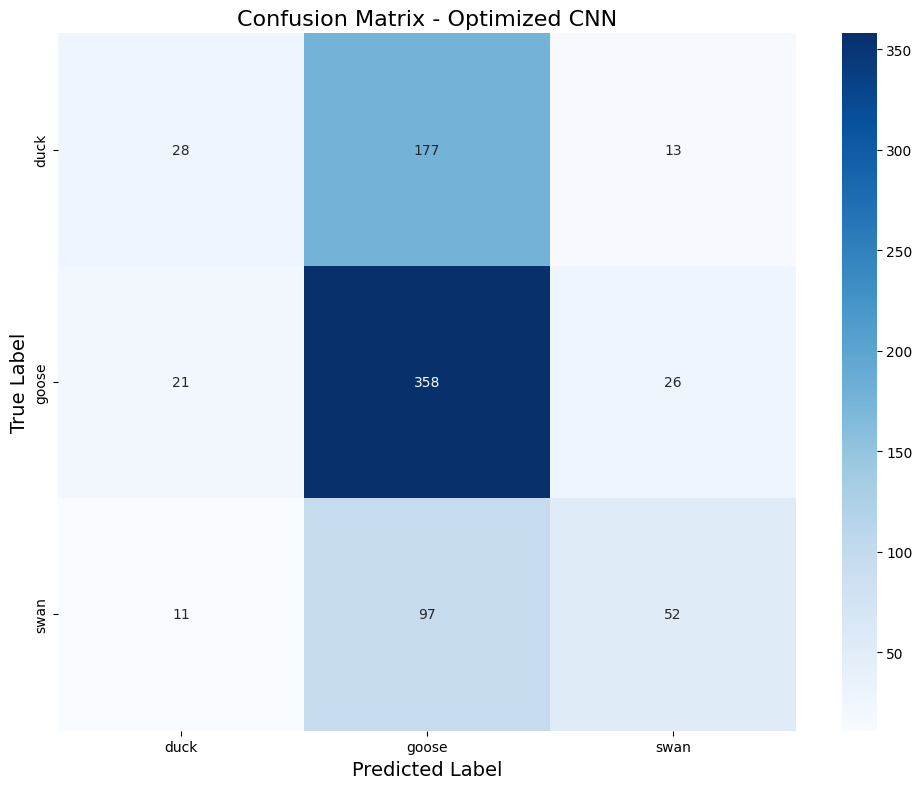


Classification Report:
              precision    recall  f1-score   support

        duck       0.47      0.13      0.20       218
       goose       0.57      0.88      0.69       405
        swan       0.57      0.33      0.41       160

    accuracy                           0.56       783
   macro avg       0.53      0.45      0.44       783
weighted avg       0.54      0.56      0.50       783



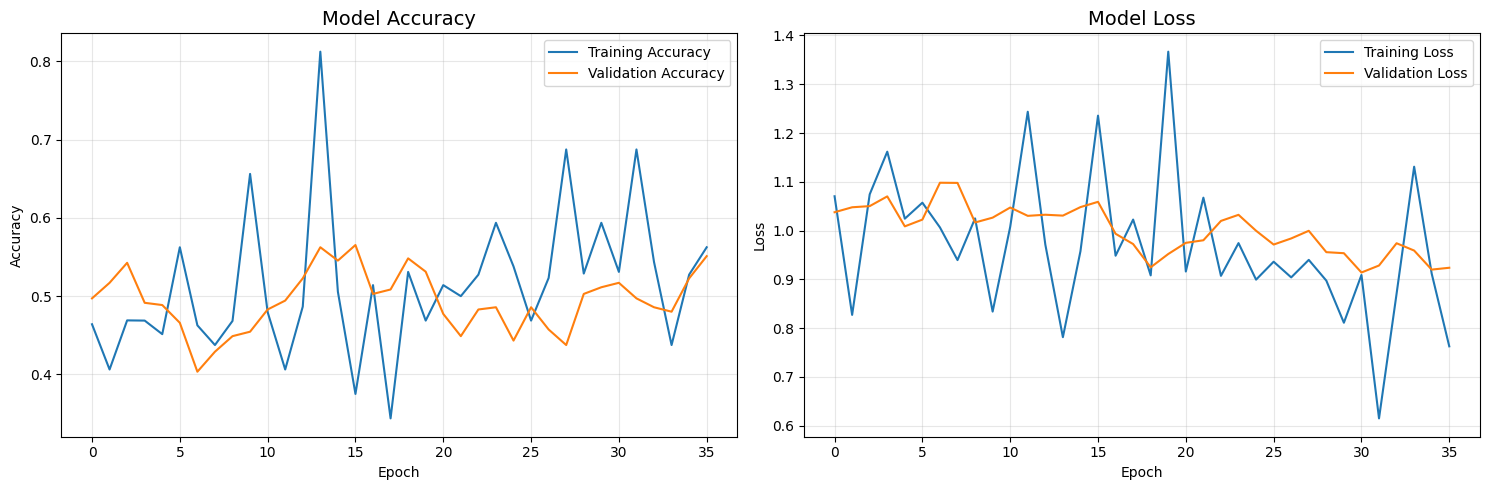

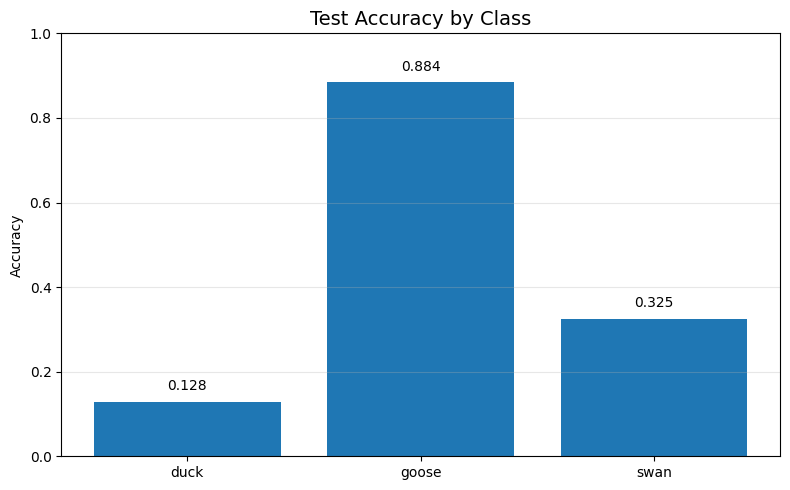


Model saved as 'final_optimized_cnn_model.h5'


In [ ]:
# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
test_generator.reset()
predictions = best_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - Optimized CNN', fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes,
                          target_names=class_names))

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
axes[0].plot(final_history.history['accuracy'], label='Training Accuracy')
axes[0].plot(final_history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(final_history.history['loss'], label='Training Loss')
axes[1].plot(final_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot accuracy by class
class_accuracies = []
for i, class_name in enumerate(class_names):
    mask = true_classes == i
    if np.sum(mask) > 0:
        class_accuracy = np.mean(predicted_classes[mask] == i)
        class_accuracies.append(class_accuracy)
    else:
        class_accuracies.append(0)

plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, class_accuracies)
plt.title('Test Accuracy by Class', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')

# Add accuracy values on bars
for bar, acc in zip(bars, class_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Save the final model
best_model.save('final_optimized_cnn_model.h5')
print("\nModel saved as 'final_optimized_cnn_model.h5'")